## REGIONES Y FRONTERAS

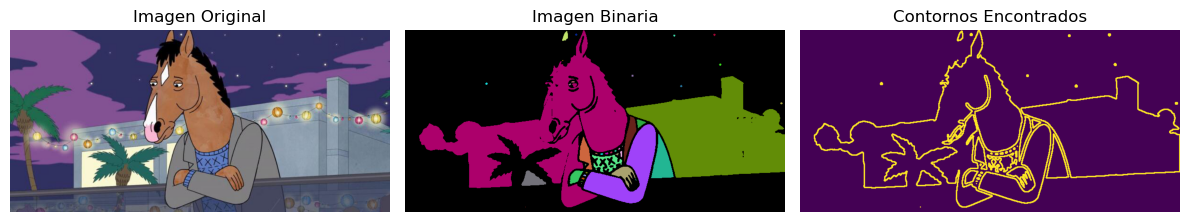

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('imagen1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #siempre convertir a escala de grises
#combiar tecnicas para preparar la imagen 
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_,binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#encontramos las regiones 
num_l, label = cv2.connectedComponents(binary)
#identificar por colores 
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
#fondo negro
color[0] = [0, 0, 0]
colorear = color[label]
#encontrar fronteras
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255,2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Imagen Binaria')
plt.imshow(colorear)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Contornos Encontrados')
plt.imshow(contorno_fin)
plt.axis('off')
plt.tight_layout()
plt.show()

## CONTEO 

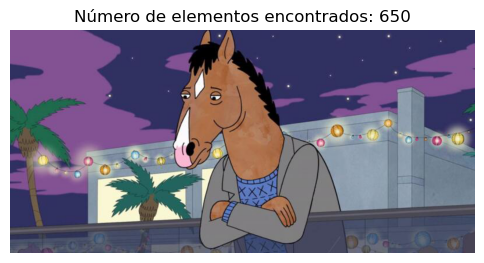

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    e_img=measure.label(binary, connectivity=2) #el pixel conectado es 4 y 1= conectividad 8
    num_obj=np.max(e_img)
    return num_obj

img = cv2.imread('imagen1.jpg')

plt.figure(figsize=(6, 6))
plt.title(f'Número de elementos encontrados: {num_elementos}')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
num_elementos = contar_elementos(img)
plt.show()

## COMBINACIONES

Total regiones: 34
color 91, 157, 19 objetos 48972
color 122, 112, 171 objetos 157
color 250, 243, 232 objetos 12
color 148, 153, 225 objetos 12
color 26, 184, 188 objetos 12
color 153, 41, 122 objetos 15
color 164, 93, 226 objetos 16
color 236, 254, 38 objetos 41483
color 217, 206, 27 objetos 15
color 246, 172, 1 objetos 15
color 207, 208, 178 objetos 12
color 144, 148, 108 objetos 12
color 5, 167, 112 objetos 1014
color 244, 60, 178 objetos 181
color 11, 141, 243 objetos 9776
color 97, 158, 241 objetos 168
color 59, 17, 174 objetos 2339
color 136, 179, 27 objetos 945
color 59, 58, 148 objetos 37
color 84, 51, 80 objetos 9
color 122, 202, 123 objetos 15
color 198, 204, 181 objetos 12
color 243, 90, 172 objetos 12
color 167, 59, 107 objetos 278
color 27, 81, 14 objetos 341
color 202, 38, 216 objetos 156
color 192, 71, 150 objetos 87
color 237, 152, 111 objetos 714
color 252, 122, 106 objetos 12
color 162, 126, 90 objetos 973
color 201, 133, 95 objetos 476
color 59, 147, 202 objetos 9
c

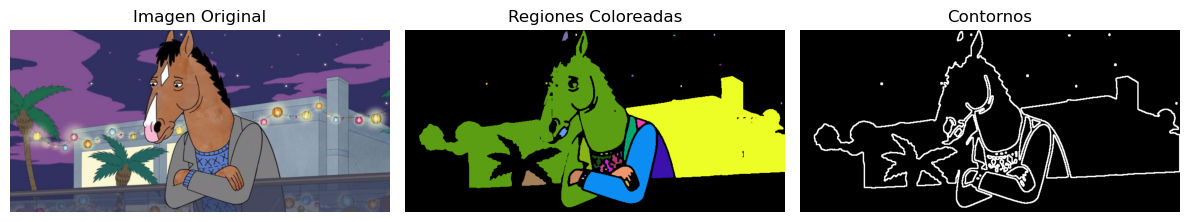

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('imagen1.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3,3), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

labels = measure.label(binary, connectivity=2)

num_regiones = labels.max()
print(f"Total regiones: {num_regiones}")

colores = np.random.randint(0, 255, size=(num_regiones + 1, 3), dtype=np.uint8)
colores[0] = [0, 0, 0]  

imagen_coloreada = colores[labels]

binary_uint8 = binary.astype(np.uint8)
contornos, _ = cv2.findContours(binary_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_img = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

for region in range(1, num_regiones + 1):
    pixeles = np.sum(labels == region)
    color = colores[region]

    print(f"color {color[0]}, {color[1]}, {color[2]} objetos {pixeles}")

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Regiones Coloreadas")
plt.imshow(imagen_coloreada)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Contornos")
plt.imshow(contorno_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()